In [1]:
!kaggle datasets download -d "adityajn105/flickr8k"

Dataset URL: https://www.kaggle.com/datasets/adityajn105/flickr8k
License(s): CC0-1.0
100% 1.04G/1.04G [00:12<00:00, 87.7MB/s]



In [2]:
import zipfile
zip_ref = zipfile.ZipFile('/content/flickr8k.zip' , 'r')
zip_ref.extractall('/content')
zip_ref.close()

In [3]:
import numpy as np
import pandas as pd
import os
import re
import pickle
import random

import tensorflow as tf

from tqdm import tqdm

from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.utils import Sequence, to_categorical
from tensorflow.keras.models import Model, load_model

from tensorflow.keras.layers import (
    Dense,
    Dropout,
    Input,
    Embedding,
    LSTM,
    Reshape,
    concatenate,
    add
)

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

from tensorflow.keras.callbacks import (ModelCheckpoint,EarlyStopping,ReduceLROnPlateau)
import matplotlib.pyplot as plt
from nltk.translate.bleu_score import (corpus_bleu,sentence_bleu,SmoothingFunction)


In [4]:
# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

In [5]:
image_path = "/content/Images"
caption_path = "/content/captions.txt"

In [6]:
data = pd.read_csv(caption_path)

print(data.head())
print("Total captions:", len(data))
print("Total unique images:", data["image"].nunique())


                       image  \
0  1000268201_693b08cb0e.jpg   
1  1000268201_693b08cb0e.jpg   
2  1000268201_693b08cb0e.jpg   
3  1000268201_693b08cb0e.jpg   
4  1000268201_693b08cb0e.jpg   

                                             caption  
0  A child in a pink dress is climbing up a set o...  
1              A girl going into a wooden building .  
2   A little girl climbing into a wooden playhouse .  
3  A little girl climbing the stairs to her playh...  
4  A little girl in a pink dress going into a woo...  
Total captions: 40455
Total unique images: 8091


In [7]:
def text_preprocessing(data):

    data = data.copy()

    # Lowercase
    data["caption"] = data["caption"].apply(lambda x: x.lower())

    # Keep only alphabets and spaces
    data["caption"] = data["caption"].apply(lambda x: re.sub(r"[^a-z\s]", "", x))

    # Remove multiple spaces
    data["caption"] = data["caption"].apply(lambda x: re.sub(r"\s+", " ", x).strip())

    # Remove words of length 1
    data["caption"] = data["caption"].apply(lambda x: " ".join([word for word in x.split() if len(word) > 1]))

    # Add start and end tokens
    data["caption"] = ("startseq " + data["caption"] + " endseq")

    return data


In [8]:
data = text_preprocessing(data)

print(data.head())

                       image  \
0  1000268201_693b08cb0e.jpg   
1  1000268201_693b08cb0e.jpg   
2  1000268201_693b08cb0e.jpg   
3  1000268201_693b08cb0e.jpg   
4  1000268201_693b08cb0e.jpg   

                                             caption  
0  startseq child in pink dress is climbing up se...  
1    startseq girl going into wooden building endseq  
2  startseq little girl climbing into wooden play...  
3  startseq little girl climbing the stairs to he...  
4  startseq little girl in pink dress going into ...  


In [9]:
images = data["image"].unique().tolist()

random.shuffle(images)

split_index = int(0.85 * len(images))

train_images = images[:split_index]
test_images = images[split_index:]

train = data[data["image"].isin(train_images)].copy()
test = data[data["image"].isin(test_images)].copy()

train.reset_index(drop=True, inplace=True)
test.reset_index(drop=True, inplace=True)

print("\nDataset split")
print("-------------------------")
print("Total images :", len(images))
print("Train images :", len(train_images))
print("Test images  :", len(test_images))

print("\nTrain captions:", len(train))
print("Test captions :", len(test))



Dataset split
-------------------------
Total images : 8091
Train images : 6877
Test images  : 1214

Train captions: 34385
Test captions : 6070


In [10]:
train_captions = train["caption"].tolist()

tokenizer = Tokenizer()
tokenizer.fit_on_texts(train_captions)

vocab_size = len(tokenizer.word_index) + 1

max_length = max(len(caption.split())for caption in train_captions)

print("\nVocabulary size:", vocab_size)
print("Maximum caption length:", max_length)


Vocabulary size: 8159
Maximum caption length: 34


In [11]:
img_size = 224

# ResNet50 with ImageNet weights
# pooling='avg' gives a 2048-dimensional feature vector

fe = ResNet50(weights="imagenet",include_top=False,pooling="avg",
              input_shape=(224, 224, 3))

# Freeze ResNet50
fe.trainable = False

print("\nResNet50 output shape:")
print(fe.output_shape)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

ResNet50 output shape:
(None, 2048)


In [12]:
batch_size = 32

features = {}

all_images = data["image"].unique().tolist()

for i in tqdm(range(0, len(all_images), batch_size),desc="Extracting ResNet50 features"):

    batch_images = all_images[i:i + batch_size]

    batch = []

    for image in batch_images:

        img = load_img(os.path.join(image_path, image),target_size=(img_size, img_size))

        img = img_to_array(img)

        # ResNet50 preprocessing
        img = preprocess_input(img)

        batch.append(img)

    batch = np.array(batch)

    batch_features = fe.predict( batch,verbose=0)

    for image, feature in zip(batch_images,batch_features):
        features[image] = feature

print("Feature extraction completed.")
print("Feature dimension:", features[all_images[0]].shape)


Extracting ResNet50 features: 100%|██████████| 253/253 [01:35<00:00,  2.66it/s]

Feature extraction completed.
Feature dimension: (2048,)


In [13]:
class CustomDataGenerator(Sequence):

    def __init__(self,df,X_col,y_col,batch_size,tokenizer,vocab_size,max_length,
                 features,shuffle=True):

        self.df = df.copy()
        self.X_col = X_col
        self.y_col = y_col

        self.batch_size = batch_size

        self.tokenizer = tokenizer
        self.vocab_size = vocab_size
        self.max_length = max_length

        self.features = features

        self.shuffle = shuffle

        self.n = len(self.df)

    def __len__(self):
        return int(np.ceil(self.n / self.batch_size))

    def on_epoch_end(self):
        if self.shuffle:
            self.df = self.df.sample(frac=1,random_state=np.random.randint(100000)).reset_index(drop=True)

    def __getitem__(self, index):
        batch = self.df.iloc[ index * self.batch_size:(index + 1) * self.batch_size]
        X1, X2, y = self.__get_data(batch)
        return (X1, X2), y

    def __get_data(self, batch):
        X1 = []
        X2 = []
        y = []
        for _, row in batch.iterrows():
            image = row[self.X_col]
            caption = row[self.y_col]
            feature = self.features[image]
            sequence = self.tokenizer.texts_to_sequences([caption])[0]

            for i in range(1, len(sequence)):

                in_seq = sequence[:i]
                out_seq = sequence[i]
                in_seq = pad_sequences([in_seq],maxlen=self.max_length,padding="pre")[0]
                out_seq = to_categorical(out_seq,num_classes=self.vocab_size)

                X1.append(feature)
                X2.append(in_seq)
                y.append(out_seq)

        return (np.array(X1),np.array(X2),np.array(y))

In [14]:
train_generator = CustomDataGenerator(
    df=train,
    X_col="image",
    y_col="caption",
    batch_size=64,
    tokenizer=tokenizer,
    vocab_size=vocab_size,
    max_length=max_length,
    features=features,
    shuffle=True)

test_generator = CustomDataGenerator(
    df=test,
    X_col="image",
    y_col="caption",
    batch_size=64,
    tokenizer=tokenizer,
    vocab_size=vocab_size,
    max_length=max_length,
    features=features,
    shuffle=False)


In [16]:
input1 = Input(shape=(2048,))

# Caption input
input2 = Input(shape=(max_length,))


# IMAGE FEATURES

img_features = Dense(256,activation="relu")(input1)

img_features = Dropout(0.3)(img_features)

img_features_reshaped = Reshape((1, 256))(img_features)

In [19]:
sentence_features = Embedding(input_dim=vocab_size,output_dim=256,mask_zero=False)(input2)

merged = concatenate([img_features_reshaped,sentence_features],axis=1)
sentence_features = LSTM(256)(merged)

x = Dropout(0.5)(sentence_features)
x = add([ x,img_features])
x = Dense(128,activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(vocab_size,activation="softmax")(x)

In [21]:
caption_model = Model(inputs=[input1, input2],outputs=output)
caption_model.compile(loss="categorical_crossentropy",optimizer="adam")
caption_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 2048)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    524,544 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_2       │ (None, 34)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 256)    │          0 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 34, 256)   │  2,088,704 │ input_layer_2[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 35, 256)   │          0 │ reshape[0][0],    │
│ (Concatenate)       │                   │            │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 256)       │    525,312 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 256)       │          0 │ dropout_1[0][0],  │
│                     │                   │            │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     32,896 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 8159)      │  1,052,511 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,223,967 (16.11 MB)

 Trainable params: 4,223,967 (16.11 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
model_name = "resnet50_caption_model.keras"

checkpoint = ModelCheckpoint(
    model_name,
    monitor="val_loss",
    mode="min",
    save_best_only=True,
    save_weights_only=False,
    verbose=1)

earlystopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    verbose=1,
    restore_best_weights=True)

learning_rate_reduction = ReduceLROnPlateau(
    monitor="val_loss",
    patience=3,
    verbose=1,
    factor=0.2,
    min_lr=1e-7)

In [23]:
history = caption_model.fit(
    train_generator,
    epochs=50,
    validation_data=test_generator,
    callbacks=[checkpoint,earlystopping,learning_rate_reduction])

Epoch 1/50


/usr/local/lib/python3.13/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


538/538 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - loss: 5.7036
Epoch 1: val_loss improved from None to 4.22206, saving model to resnet50_caption_model.keras

Epoch 1: finished saving model to resnet50_caption_model.keras
538/538 ━━━━━━━━━━━━━━━━━━━━ 71s 122ms/step - loss: 5.1178 - val_loss: 4.2221 - learning_rate: 0.0010
Epoch 2/50
538/538 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - loss: 4.3759
Epoch 2: val_loss improved from 4.22206 to 3.89316, saving model to resnet50_caption_model.keras

Epoch 2: finished saving model to resnet50_caption_model.keras
538/538 ━━━━━━━━━━━━━━━━━━━━ 65s 121ms/step - loss: 4.3031 - val_loss: 3.8932 - learning_rate: 0.0010
Epoch 3/50
538/538 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - loss: 4.0739
Epoch 3: val_loss improved from 3.89316 to 3.74148, saving model to resnet50_caption_model.keras

Epoch 3: finished saving model to resnet50_caption_model.keras
538/538 ━━━━━━━━━━━━━━━━━━━━ 65s 121ms/step - loss: 4.0407 - val_loss: 3.7415 - learning_rate: 0.0010
Epoch 4/50
538/538

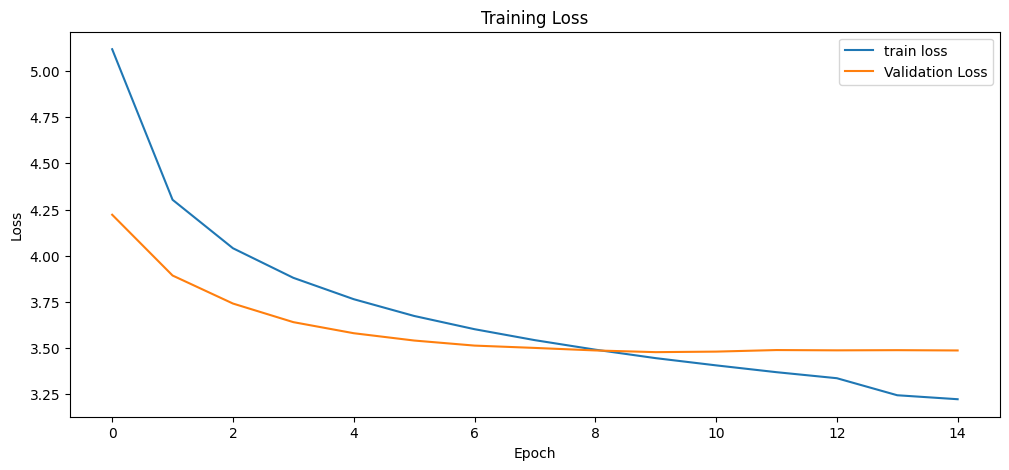

In [24]:
plt.figure(figsize=(12, 5))
plt.plot(history.history["loss"], label="train loss")
plt.plot( history.history['val_loss'],label='Validation Loss')
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


In [25]:
# Save tokenizer
with open("tokenizer.pkl","wb") as f:

    pickle.dump(tokenizer,f)

# Save ResNet50 feature extractor
fe.save("resnet50_feature_extractor.keras")

print("Tokenizer saved.")
print("ResNet50 feature extractor saved.")

Tokenizer saved.
ResNet50 feature extractor saved.


In [69]:
def generate_caption(image_path,caption_model,tokenizer,
                     feature_extractor,max_length,img_size=224):
    # Load image
    img = load_img(image_path,target_size=(img_size,img_size))

    # Convert image to array
    img = img_to_array(img)

    # ResNet50 preprocessing
    img = preprocess_input(img)

    # Add batch dimension
    img = np.expand_dims(img,axis=0)

    # Extract image features
    image_features = feature_extractor.predict(
        img,
        verbose=0
    )

    # Start caption
    in_text = "startseq"

    for _ in range(max_length):

        sequence = tokenizer.texts_to_sequences([in_text])[0]

        sequence = pad_sequences([sequence],maxlen=max_length)

        # Predict next word
        yhat = caption_model.predict([image_features,sequence],verbose=0)

        yhat_index = np.argmax(yhat)

        word = tokenizer.index_word.get(yhat_index)

        if word is None:
            break
        in_text += " " + word
        if word == "endseq":
            break

    caption = (in_text.replace("startseq", "").replace("endseq", "").strip())

    return caption

Image: 2477121456_1ac5c6d3e4.jpg
Generated Caption: black dog is swimming in the water


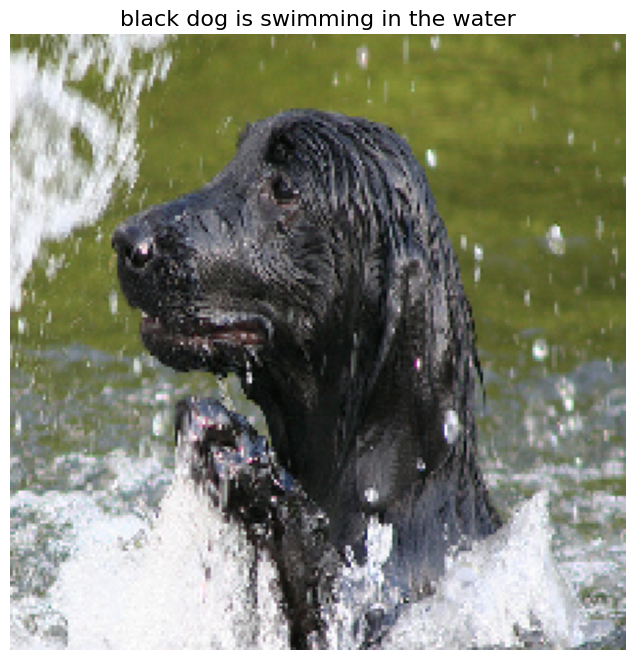

In [71]:
test_image = test_images[1]

test_image_path = os.path.join(image_path,test_image)

caption = generate_caption(test_image_path,caption_model,tokenizer,fe,max_length)

print("Image:", test_image)
print("Generated Caption:", caption)

img = load_img(test_image_path,target_size=(224, 224))

plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.axis('off')
plt.title(caption,fontsize=16)
plt.show()

Image: 1772859261_236c09b861.jpg
Generated Caption: dog is running through the water


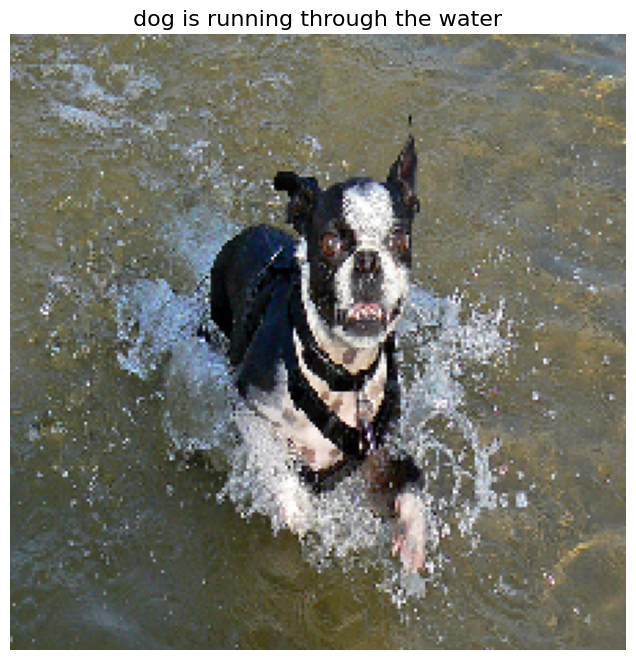

In [72]:
test_image = test_images[2]

test_image_path = os.path.join(image_path,test_image)

caption = generate_caption(test_image_path,caption_model,tokenizer,fe,max_length)

print("Image:", test_image)
print("Generated Caption:", caption)

img = load_img(test_image_path,target_size=(224, 224))

plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.axis('off')
plt.title(caption,fontsize=16)
plt.show()

Image: 3341477531_4e37450f35.jpg
Generated Caption: man is jumping over the skateboard


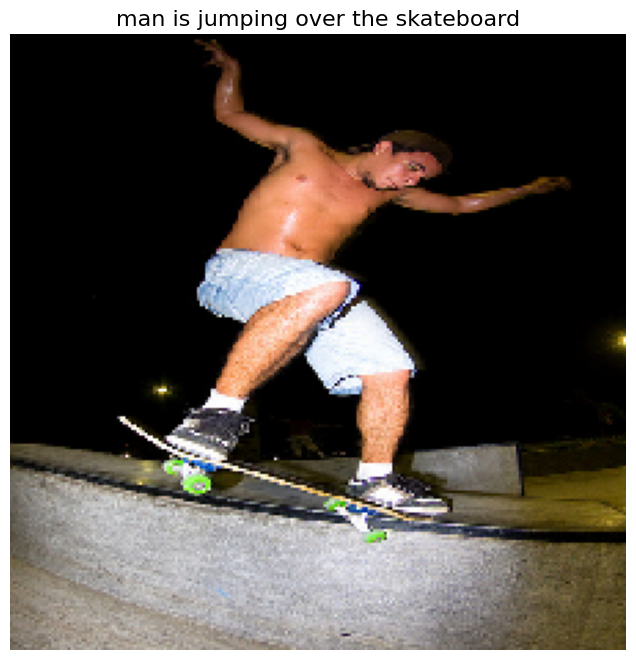

In [79]:
test_image = test_images[10]

test_image_path = os.path.join(image_path,test_image)

caption = generate_caption(test_image_path,caption_model,tokenizer,fe,max_length)

print("Image:", test_image)
print("Generated Caption:", caption)

img = load_img(test_image_path, target_size=(224, 224))
plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.axis('off')
plt.title(caption,fontsize=16)
plt.show()

In [80]:
# BLEU SCORE ON UNSEEN TEST SET
# BLEU-1, BLEU-2, BLEU-3, BLEU-4
smoothie = SmoothingFunction().method4

# Group all test captions by image
test_references = (
    test.groupby("image")["caption"] .apply(list).to_dict())

references = []
hypotheses = []

for image_name in tqdm(test_references.keys(),desc="Calculating BLEU"):

    image_file = os.path.join(image_path,image_name)

    # Generate caption
    prediction = generate_caption(image_file,caption_model,tokenizer,fe,max_length)

    # Candidate caption
    candidate = prediction.split()

    # Ground-truth captions
    refs = []

    for ref in test_references[image_name]:
        ref_words = (ref.replace("startseq ", "").replace(" endseq", "").split())
        refs.append(ref_words)
    references.append(refs)
    hypotheses.append(candidate)

Calculating BLEU: 100%|██████████| 1214/1214 [16:41<00:00,  1.21it/s]


In [81]:
# BLEU-1
bleu1 = corpus_bleu(
    references,
    hypotheses,
    weights=(1, 0, 0, 0),
    smoothing_function=smoothie)


# BLEU-2
bleu2 = corpus_bleu(
    references,
    hypotheses,
    weights=(0.5, 0.5, 0, 0),
    smoothing_function=smoothie)


# BLEU-3
bleu3 = corpus_bleu(
    references,
    hypotheses,
    weights=(1/3,1/3,1/3,0),
    smoothing_function=smoothie)


# BLEU-4
bleu4 = corpus_bleu(
    references,
    hypotheses,
    weights=(0.25,0.25,0.25,0.25),smoothing_function=smoothie)

print("=" * 40)
print("BLEU SCORES ON TEST SET")
print("=" * 40)

print(f"BLEU-1: {bleu1:.4f}")
print(f"BLEU-2: {bleu2:.4f}")
print(f"BLEU-3: {bleu3:.4f}")
print(f"BLEU-4: {bleu4:.4f}")

BLEU SCORES ON TEST SET
BLEU-1: 0.5070
BLEU-2: 0.3078
BLEU-3: 0.1789
BLEU-4: 0.1023


In [82]:
sample_images = test_images[:10]

for image_name in sample_images:
    image_file = os.path.join(image_path,image_name )

    prediction = generate_caption(
        image_file,
        caption_model,
        tokenizer,
        fe,
        max_length)
    actual_captions = test[test["image"] == image_name]["caption"].tolist()

    print("\n" + "=" * 70)

    print("IMAGE:", image_name)
    print("\nGenerated Caption:")
    print(prediction)

    print("\nGround Truth Captions:")

    for caption in actual_captions:
        print(caption.replace("startseq ", "").replace(" endseq", ""))


IMAGE: 2089542487_b4c1ee7025.jpg

Generated Caption:
man in red shirt is standing on the edge of the water

Ground Truth Captions:
hiker is ready to take on rugged outdoor trail
lone hiker on dirt hiking trail with hat and sunglasses on with trees in the background
man in shorts is hiking in dry region
man stops for picture with the scenery during his hike
the man is posing for picture in the desert wearing green shirt and hat and holding metal detector

IMAGE: 2477121456_1ac5c6d3e4.jpg

Generated Caption:
black dog is swimming in the water

Ground Truth Captions:
black dog plays in the water
black dog head rises above some water
black dog splashes in the water
drenched black labrador in the water
the black dog head is poking up out of the water

IMAGE: 1772859261_236c09b861.jpg

Generated Caption:
dog is running through the water

Ground Truth Captions:
black and white dog plays in the water
black and white dog walking in shallow water
dog splashes through the water
dog swims
black a